# 16 Figure 5 Descriptor Origins of Internal Resistance

Purpose:
This notebook prepares draft plots and exported data for Figure 5.

Figure 5A:
- Inorganic electrolyte presence vs log(R)

Figure 5B:
- Ion type vs log(R)

Figure 5C:
- Structure class vs log(R)

Figure 5D:
- Conceptual schematic summarizing descriptor origins of internal resistance

Important:
Only records with observed internal resistance are used for Figure 5A–C.
Missing R values are not imputed or assigned to any R-related group.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print("scipy is not available. Statistical tests will be skipped.")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

out_dir = Path("../results/figure5_R_origin")
out_dir.mkdir(parents=True, exist_ok=True)

print("Output folder:", out_dir.resolve())

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.linewidth"] = 1.0

Output folder: <REPOSITORY_ROOT>\results\figure5_R_origin


In [2]:
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#000000",
    "gray": "#666666",
    "light_gray": "#DDDDDD",
    "very_light_gray": "#F2F2F2"
}

PANEL_COLORS = [
    COLORS["blue"],
    COLORS["orange"],
    COLORS["green"],
    COLORS["purple"],
    COLORS["gray"],
]

In [3]:
candidate_files = [
    "hydrovoltaic_dataset_phase2_input_utf8.csv",
    "hydrovoltaic_model_input.csv",
    "hydrovoltaic_clean.csv",
    "../data/processed/hydrovoltaic_dataset_phase2_input_utf8.csv",
    "../data/processed/hydrovoltaic_model_input.csv",
    "../data/processed/hydrovoltaic_clean.csv",
    "../notebooks/hydrovoltaic_dataset_phase2_input_utf8.csv",
    "../notebooks/hydrovoltaic_model_input.csv",
    "../notebooks/hydrovoltaic_clean.csv",
]

data_path = None

for f in candidate_files:
    p = Path(f)
    if p.exists():
        data_path = p
        break

if data_path is None:
    print("CSV files found in current folder:")
    for f in Path(".").glob("*.csv"):
        print(" -", f.name)
    print("CSV files found in parent folder:")
    for f in Path("..").glob("*.csv"):
        print(" -", f.name)
    raise FileNotFoundError("Please update candidate_files with the correct dataset path.")

df = pd.read_csv(data_path, encoding="utf-8-sig")

print("Loaded:", data_path)
print("Dataset shape:", df.shape)
display(df.head())

Loaded: hydrovoltaic_dataset_phase2_input_utf8.csv
Dataset shape: (159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,auxiliary_redox_present,continuous_output,water_interaction_mode,rh_percent,inorganic_electrolyte_present,inorganic_electrolyte_type,inorganic_electrolyte_concentration_wt%,polyelectrolyte_present,active_material_raw,material_class,structure_class,ionic_groups,top_electrode,bottom_electrode,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_Mohm,output_timescale_class,stability_time_min,dominant_mechanism,has_anionic,has_cationic,has_zwitterionic,polyelectrolyte_anionic_raw,polyelectrolyte_cationic_raw,polyelectrolyte_zwitterionic_raw,has_any_polyelectrolyte,estimated_power_density_uW_cm2,log_estimated_power_density,ion_type,asym_env,asym_chem,asym_electrode,mechanism_simple,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,60.0,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,0,0,0,NaN,NaN,NaN,0,0.003750,-2.425853,proton,1,0,0,streaming,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,0,1,evaporation_driven,62.0,0,NaN,NaN,0,ZnO,metal oxide,porous,hydroxyl,Al,Al,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,0,0,0,NaN,NaN,NaN,0,0.002000,-2.698753,anion,1,0,0,streaming,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,lanthanum iron perovskite oxide,semiconductor,porous,hydroxyl,CNT,CNT,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,0,0,0,NaN,NaN,NaN,0,0.009375,-2.027982,anion,1,1,0,streaming,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,0,0,0,NaN,NaN,NaN,0,0.007820,-2.106738,proton,1,0,0,streaming,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,55.0,0,NaN,NaN,0,carbonized rice husk,carbon,porous,"carboxyl, hydroxyl, silanol",CNT,CNT,1,0.0,0.16,0.0400,NaN,NaN,hours,600.0,streaming,0,0,0,NaN,NaN,NaN,0,0.001600,-2.795609,proton,1,0,0,streaming,1,0,0,NaN,0


In [4]:
def find_first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def find_column_by_keywords(df, keywords):
    keywords = [k.lower() for k in keywords]
    for c in df.columns:
        c_low = c.lower()
        if all(k in c_low for k in keywords):
            return c
    return None


def show_candidate_columns(df, keyword):
    return [c for c in df.columns if keyword.lower() in c.lower()]

In [5]:
# Internal resistance columns
R_log_candidates = [
    "log_internal_resistance_Mohm",
    "log_internal_resistance_MΩ",
    "log_R",
    "logR",
]

R_raw_candidates = [
    "internal_resistance_Mohm",
    "internal_resistance_MΩ",
    "internal_resistance",
    "R_Mohm",
]

# Descriptor columns
inorganic_candidates = [
    "inorganic_electrolyte_present",
    "electrolyte_inorganic_present",
    "has_inorganic_electrolyte",
]

ion_candidates = [
    "ion_type",
    "primary_mobile_ion_type",
    "mobile_ion_type",
]

structure_candidates = [
    "structure_class",
    "device_structure",
    "structure",
]

R_log_col = find_first_existing_column(df, R_log_candidates)
R_raw_col = find_first_existing_column(df, R_raw_candidates)

INORG_COL = find_first_existing_column(df, inorganic_candidates)
ION_COL = find_first_existing_column(df, ion_candidates)
STRUCT_COL = find_first_existing_column(df, structure_candidates)

# Fallbacks
if R_log_col is None:
    R_log_col = find_column_by_keywords(df, ["log", "resistance"])

if R_raw_col is None:
    R_raw_col = find_column_by_keywords(df, ["resistance"])

if INORG_COL is None:
    INORG_COL = find_column_by_keywords(df, ["inorganic", "electrolyte"])

if ION_COL is None:
    ION_COL = find_column_by_keywords(df, ["ion", "type"])

if STRUCT_COL is None:
    STRUCT_COL = find_column_by_keywords(df, ["structure"])

print("Detected columns:")
print("R_log_col:", R_log_col)
print("R_raw_col:", R_raw_col)
print("INORG_COL:", INORG_COL)
print("ION_COL:", ION_COL)
print("STRUCT_COL:", STRUCT_COL)

print("\nColumns containing 'electrolyte':", show_candidate_columns(df, "electrolyte"))
print("Columns containing 'ion':", show_candidate_columns(df, "ion"))
print("Columns containing 'structure':", show_candidate_columns(df, "structure"))
print("Columns containing 'resistance':", show_candidate_columns(df, "resistance"))

Detected columns:
R_log_col: log_internal_resistance_Mohm
R_raw_col: internal_resistance_Mohm
INORG_COL: inorganic_electrolyte_present
ION_COL: ion_type
STRUCT_COL: structure_class

Columns containing 'electrolyte': ['inorganic_electrolyte_present', 'inorganic_electrolyte_type', 'inorganic_electrolyte_concentration_wt%', 'polyelectrolyte_present', 'polyelectrolyte_anionic_raw', 'polyelectrolyte_cationic_raw', 'polyelectrolyte_zwitterionic_raw', 'has_any_polyelectrolyte', 'ion_from_electrolyte']
Columns containing 'ion': ['primary_mobile_ion', 'secondary_ion_present', 'secondary_mobile_ion', 'ion_origin', 'water_interaction_mode', 'inorganic_electrolyte_concentration_wt%', 'ionic_groups', 'has_anionic', 'has_cationic', 'has_zwitterionic', 'polyelectrolyte_anionic_raw', 'polyelectrolyte_cationic_raw', 'polyelectrolyte_zwitterionic_raw', 'ion_type', 'ion_from_material', 'ion_from_electrolyte', 'ion_from_water']
Columns containing 'structure': ['device_structure', 'structure_class']
Column

In [6]:
# Build observed-R dataframe
df5 = df.copy()

# Build log(R)
if R_log_col is not None:
    df5["log_R"] = pd.to_numeric(df5[R_log_col], errors="coerce")
elif R_raw_col is not None:
    raw_R = pd.to_numeric(df5[R_raw_col], errors="coerce")
    df5["log_R"] = np.log10(raw_R.where(raw_R > 0))
else:
    raise ValueError("No internal resistance column was found.")

# Keep only records with observed internal resistance
df_R = df5.dropna(subset=["log_R"]).copy()

EXPECTED_N_R = 112

print("Total records:", len(df5))
print("Observed R records:", len(df_R))
print("Missing R records:", df5["log_R"].isna().sum())

if len(df_R) != EXPECTED_N_R:
    print(f"Warning: observed-R count is {len(df_R)}, not {EXPECTED_N_R}. Check dataset version.")

display(df_R[["log_R"]].describe())

Total records: 159
Observed R records: 112
Missing R records: 47


,log_R
count,112.000000
mean,-0.671009
std,1.363584
min,-3.468521
25%,-1.704539
50%,-0.903438
75%,0.182418
max,3.000000


In [7]:
# Clean grouping variables
# 5A: inorganic electrolyte presence
if INORG_COL is None:
    raise ValueError("No inorganic electrolyte descriptor was found. Please set INORG_COL manually.")

df_R["inorganic_electrolyte_group"] = pd.to_numeric(df_R[INORG_COL], errors="coerce")

# If values are strings, handle them
if df_R["inorganic_electrolyte_group"].isna().all():
    tmp = df_R[INORG_COL].astype(str).str.lower().str.strip()
    df_R["inorganic_electrolyte_group"] = np.where(
        tmp.isin(["1", "yes", "true", "present", "with", "with inorganic electrolyte"]),
        1,
        np.where(
            tmp.isin(["0", "no", "false", "absent", "without", "without inorganic electrolyte"]),
            0,
            np.nan
        )
    )

df_R["inorganic_electrolyte_group"] = df_R["inorganic_electrolyte_group"].map({
    0: "without_inorganic_electrolyte",
    1: "with_inorganic_electrolyte"
})

# 5B: ion type
if ION_COL is None:
    raise ValueError("No ion type column was found. Please set ION_COL manually.")

df_R["ion_type_clean"] = (
    df_R[ION_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# 5C: structure class
if STRUCT_COL is None:
    raise ValueError("No structure class column was found. Please set STRUCT_COL manually.")

df_R["structure_class_clean"] = (
    df_R[STRUCT_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("Inorganic electrolyte groups:")
display(df_R["inorganic_electrolyte_group"].value_counts(dropna=False))

print("Ion types:")
display(df_R["ion_type_clean"].value_counts(dropna=False))

print("Structure classes:")
display(df_R["structure_class_clean"].value_counts(dropna=False))

Inorganic electrolyte groups:


inorganic_electrolyte_group
without_inorganic_electrolyte    71
with_inorganic_electrolyte       41
Name: count, dtype: int64

Ion types:


ion_type_clean
proton          62
other_cation    42
anion            8
Name: count, dtype: int64

Structure classes:


structure_class_clean
porous               84
film                 13
hydrogel             10
hydrogel_+_porous     4
hydrogel_+_film       1
Name: count, dtype: int64

In [8]:
# Summary tables and statistical tests
def group_summary(df, group_col, value_col="log_R", order=None):
    d = df.dropna(subset=[group_col, value_col]).copy()
    
    summary = (
        d.groupby(group_col)[value_col]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reset_index()
    )
    
    if order is not None:
        summary[group_col] = pd.Categorical(summary[group_col], categories=order, ordered=True)
        summary = summary.sort_values(group_col).reset_index(drop=True)
    
    return summary


def run_group_test(df, group_col, value_col="log_R", order=None):
    d = df.dropna(subset=[group_col, value_col]).copy()
    
    if order is None:
        groups = list(d[group_col].dropna().unique())
    else:
        groups = [g for g in order if g in set(d[group_col])]
    
    arrays = [d.loc[d[group_col] == g, value_col].values for g in groups]
    arrays = [a for a in arrays if len(a) > 0]
    
    if not SCIPY_AVAILABLE:
        return {"test": "not_run", "p_value": np.nan}
    
    if len(arrays) == 2:
        stat, p = stats.mannwhitneyu(arrays[0], arrays[1], alternative="two-sided")
        return {"test": "Mann-Whitney U", "statistic": stat, "p_value": p}
    
    if len(arrays) > 2:
        stat, p = stats.kruskal(*arrays)
        return {"test": "Kruskal-Wallis", "statistic": stat, "p_value": p}
    
    return {"test": "not_enough_groups", "p_value": np.nan}


inorg_order = [
    "without_inorganic_electrolyte",
    "with_inorganic_electrolyte"
]

ion_order = [
    "proton",
    "other_cation",
    "anion"
]

# R1C6: retain hybrids in the descriptive dataset, but exclude them from
# direct structure-level internal-resistance inference.
structure_order = ["porous", "film", "hydrogel"]
df_R_structure_inference = df_R.loc[
    df_R["structure_class_clean"].isin(structure_order)
].copy()

fig5A_summary = group_summary(df_R, "inorganic_electrolyte_group", order=inorg_order)
fig5B_summary = group_summary(df_R, "ion_type_clean", order=ion_order)
fig5C_summary = group_summary(
    df_R_structure_inference, "structure_class_clean", order=structure_order
)

fig5_tests = pd.DataFrame([
    {"panel": "Fig5A", "comparison": "inorganic electrolyte presence", **run_group_test(df_R, "inorganic_electrolyte_group", order=inorg_order)},
    {"panel": "Fig5B", "comparison": "ion type", **run_group_test(df_R, "ion_type_clean", order=ion_order)},
    {"panel": "Fig5C", "comparison": "structure class", **run_group_test(df_R_structure_inference, "structure_class_clean", order=structure_order)},
])

display(fig5A_summary)
display(fig5B_summary)
display(fig5C_summary)
display(fig5_tests)

,inorganic_electrolyte_group,count,mean,median,std,min,max
0,without_inorganic_electrolyte,71,-0.234584,0.000000,1.351894,-3.301030,3.00000
1,with_inorganic_electrolyte,41,-1.426768,-1.657577,1.018760,-3.468521,0.90309


,ion_type_clean,count,mean,median,std,min,max
0,proton,62,-0.236174,0.000000,1.353036,-3.301030,3.000000
1,other_cation,42,-1.403316,-1.638683,1.045740,-3.468521,0.903090
2,anion,8,-0.196365,-0.183620,1.405647,-2.000000,1.778151


,structure_class_clean,count,mean,median,std,min,max
0,porous,84,-0.429170,-0.227966,1.370990,-3.468521,3.000000
1,film,13,-0.946162,-1.000000,1.172801,-3.301030,1.301030
2,hydrogel,10,-1.708592,-2.000000,0.915122,-3.000000,0.342423
3,hydrogel_+_porous,4,-2.079690,-1.849485,0.635027,-3.000000,-1.619789
4,hydrogel_+_film,1,-1.397940,-1.397940,NaN,-1.397940,-1.397940


,panel,comparison,test,statistic,p_value
0,Fig5A,inorganic electrolyte presence,Mann-Whitney U,2218.000000,0.000004
1,Fig5B,ion type,Kruskal-Wallis,20.407733,0.000037
2,Fig5C,structure class,Kruskal-Wallis,13.753155,0.008126


In [9]:
def plot_violin_box_jitter(
    ax,
    df,
    group_col,
    value_col,
    order,
    label_map=None,
    colors=None,
    title="",
    ylabel=r"$\log(R)$",
    ylim=None,
    rotate=0,
    show_n=True,
    seed=42,
):
    d = df.dropna(subset=[group_col, value_col]).copy()
    
    order = [g for g in order if g in set(d[group_col])]
    data = [d.loc[d[group_col] == g, value_col].values for g in order]
    
    positions = np.arange(1, len(order) + 1)
    
    if colors is None:
        colors = PANEL_COLORS[:len(order)]
    
    # Violin
    viol = ax.violinplot(
        data,
        positions=positions,
        widths=0.72,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )
    
    for body, color in zip(viol["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("none")
        body.set_alpha(0.18)
    
    # Boxplot
    box = ax.boxplot(
        data,
        positions=positions,
        widths=0.32,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="white", linewidth=1.5),
        boxprops=dict(linewidth=1.1),
        whiskerprops=dict(linewidth=1.1),
        capprops=dict(linewidth=1.1)
    )
    
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor(color)
    
    for whisker in box["whiskers"]:
        whisker.set_color(COLORS["gray"])
    for cap in box["caps"]:
        cap.set_color(COLORS["gray"])
    
    # Jittered points
    rng = np.random.default_rng(seed)
    for i, (g, color) in enumerate(zip(order, colors), start=1):
        y = d.loc[d[group_col] == g, value_col].values
        x = rng.normal(loc=i, scale=0.055, size=len(y))
        ax.scatter(
            x,
            y,
            s=18,
            alpha=0.42,
            color=color,
            edgecolor="none"
        )
        
        if show_n:
            ax.text(
                i,
                ax.get_ylim()[0] if ylim is None else ylim[0],
                f"n={len(y)}",
                ha="center",
                va="bottom",
                fontsize=8,
                color=COLORS["gray"]
            )
    
    labels = [label_map.get(g, g) if label_map else g for g in order]
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=rotate, ha="right" if rotate else "center")
    
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    
    if ylim is not None:
        ax.set_ylim(ylim)
    
    ax.axhline(0, linestyle="--", linewidth=1, color=COLORS["light_gray"])
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    return ax

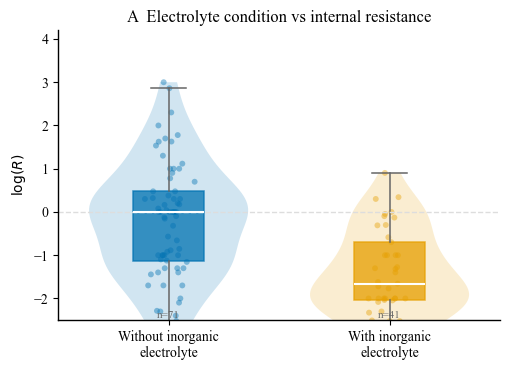

In [10]:
# Fig. 5A draft plot
fig, ax = plt.subplots(figsize=(5.2, 3.8))

fig5A_labels = {
    "without_inorganic_electrolyte": "Without inorganic\nelectrolyte",
    "with_inorganic_electrolyte": "With inorganic\nelectrolyte",
}

plot_violin_box_jitter(
    ax=ax,
    df=df_R,
    group_col="inorganic_electrolyte_group",
    value_col="log_R",
    order=inorg_order,
    label_map=fig5A_labels,
    colors=[COLORS["blue"], COLORS["orange"]],
    title="A  Electrolyte condition vs internal resistance",
    ylabel=r"$\log(R)$",
    ylim=(-2.5, 4.2),
    rotate=0,
)

plt.tight_layout()
plt.show()

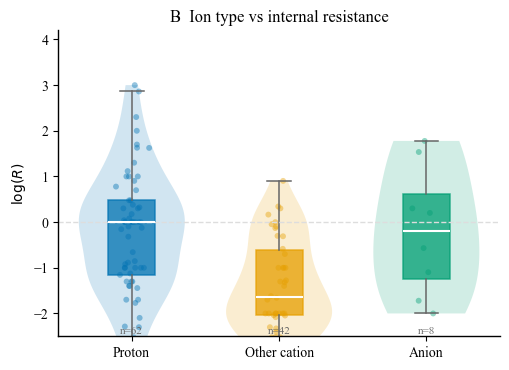

In [11]:
# Fig. 5B draft plot
fig, ax = plt.subplots(figsize=(5.2, 3.8))

fig5B_labels = {
    "proton": "Proton",
    "other_cation": "Other cation",
    "anion": "Anion",
}

plot_violin_box_jitter(
    ax=ax,
    df=df_R,
    group_col="ion_type_clean",
    value_col="log_R",
    order=ion_order,
    label_map=fig5B_labels,
    colors=[COLORS["blue"], COLORS["orange"], COLORS["green"]],
    title="B  Ion type vs internal resistance",
    ylabel=r"$\log(R)$",
    ylim=(-2.5, 4.2),
    rotate=0,
)

plt.tight_layout()
plt.show()

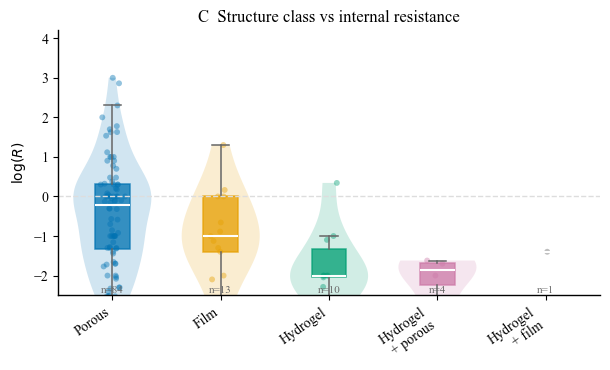

In [12]:
# Fig. 5C draft plot
fig, ax = plt.subplots(figsize=(6.2, 3.8))

fig5C_labels = {
    "porous": "Porous",
    "film": "Film",
    "hydrogel": "Hydrogel",
    "hydrogel_+_porous": "Hydrogel\n+ porous",
    "hydrogel+porous": "Hydrogel\n+ porous",
    "hydrogel_+_film": "Hydrogel\n+ film",
    "hydrogel+film": "Hydrogel\n+ film",
}

plot_violin_box_jitter(
    ax=ax,
    df=df_R,
    group_col="structure_class_clean",
    value_col="log_R",
    order=structure_order,
    label_map=fig5C_labels,
    colors=PANEL_COLORS,
    title="C  Structure class vs internal resistance",
    ylabel=r"$\log(R)$",
    ylim=(-2.5, 4.2),
    rotate=35,
)

plt.tight_layout()
plt.show()

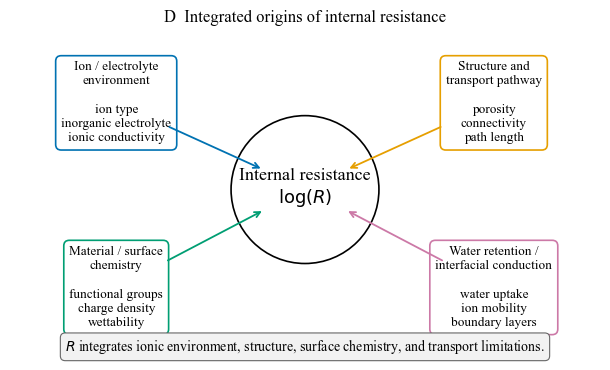

In [13]:
# Fig. 5D conceptual schematic
fig, ax = plt.subplots(figsize=(6.2, 3.8))

ax.axis("off")

# Center node
ax.text(
    0.50, 0.52,
    "Internal resistance\n" + r"$\log(R)$",
    ha="center",
    va="center",
    fontsize=13,
    bbox=dict(boxstyle="circle,pad=0.45", fc="white", ec=COLORS["black"], lw=1.2)
)

# Box positions and content
boxes = [
    {
        "xy": (0.18, 0.78),
        "title": "Ion / electrolyte\nenvironment",
        "items": "ion type\ninorganic electrolyte\nionic conductivity",
        "color": COLORS["blue"],
    },
    {
        "xy": (0.82, 0.78),
        "title": "Structure and\ntransport pathway",
        "items": "porosity\nconnectivity\npath length",
        "color": COLORS["orange"],
    },
    {
        "xy": (0.18, 0.22),
        "title": "Material / surface\nchemistry",
        "items": "functional groups\ncharge density\nwettability",
        "color": COLORS["green"],
    },
    {
        "xy": (0.82, 0.22),
        "title": "Water retention /\ninterfacial conduction",
        "items": "water uptake\nion mobility\nboundary layers",
        "color": COLORS["purple"],
    },
]

for b in boxes:
    x, y = b["xy"]
    text = b["title"] + "\n\n" + b["items"]
    ax.text(
        x, y,
        text,
        ha="center",
        va="center",
        fontsize=9.5,
        linespacing=1.25,
        bbox=dict(
            boxstyle="round,pad=0.42",
            fc="white",
            ec=b["color"],
            lw=1.2
        )
    )
    
    # Arrow to center
    ax.annotate(
        "",
        xy=(0.50, 0.52),
        xytext=(x, y),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.3,
            color=b["color"],
            shrinkA=42,
            shrinkB=35
        )
    )

# Bottom statement
ax.text(
    0.50, 0.04,
    r"$R$ integrates ionic environment, structure, surface chemistry, and transport limitations.",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", fc=COLORS["very_light_gray"], ec=COLORS["gray"], lw=0.8)
)

ax.set_title("D  Integrated origins of internal resistance")

plt.tight_layout()
plt.show()

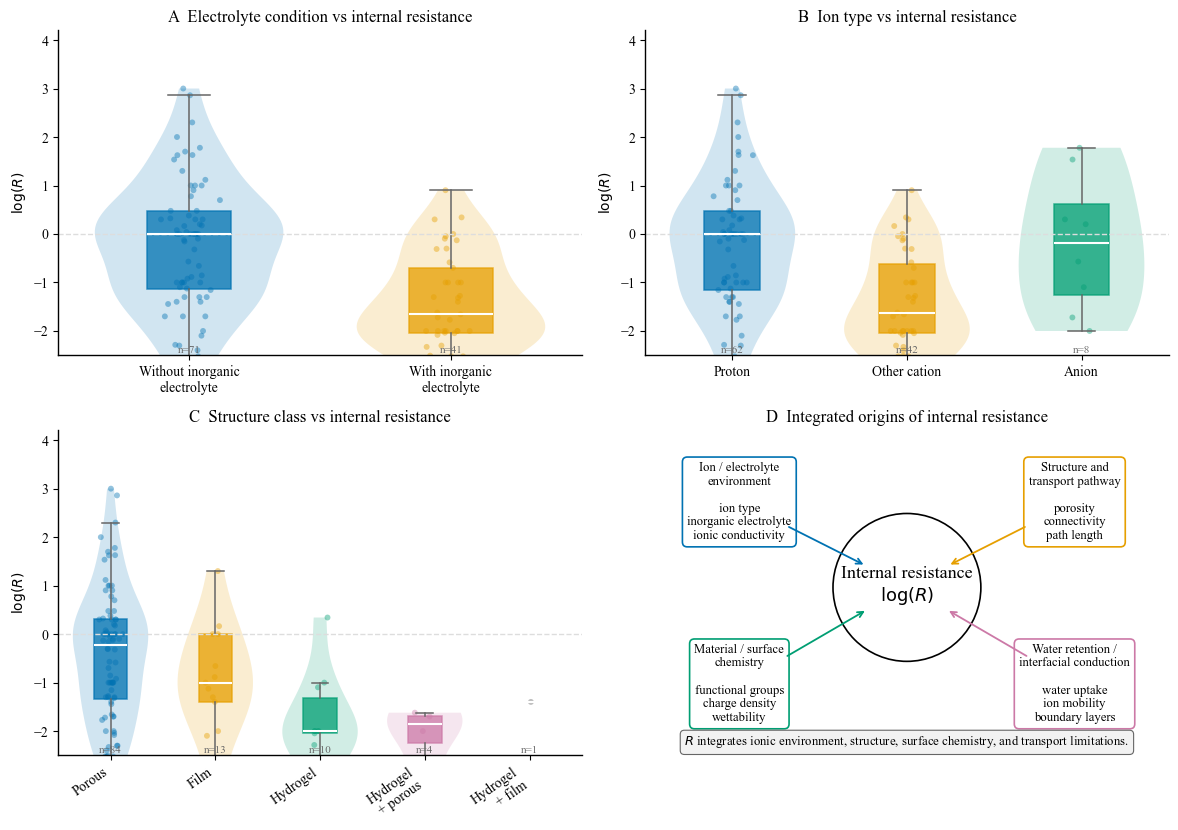

In [14]:
# Combined Figure 5 draft
fig, axes = plt.subplots(2, 2, figsize=(12, 8.4))

# =========================
# A. Electrolyte condition
# =========================
ax = axes[0, 0]
plot_violin_box_jitter(
    ax=ax,
    df=df_R,
    group_col="inorganic_electrolyte_group",
    value_col="log_R",
    order=inorg_order,
    label_map=fig5A_labels,
    colors=[COLORS["blue"], COLORS["orange"]],
    title="A  Electrolyte condition vs internal resistance",
    ylabel=r"$\log(R)$",
    ylim=(-2.5, 4.2),
    rotate=0,
)

# =========================
# B. Ion type
# =========================
ax = axes[0, 1]
plot_violin_box_jitter(
    ax=ax,
    df=df_R,
    group_col="ion_type_clean",
    value_col="log_R",
    order=ion_order,
    label_map=fig5B_labels,
    colors=[COLORS["blue"], COLORS["orange"], COLORS["green"]],
    title="B  Ion type vs internal resistance",
    ylabel=r"$\log(R)$",
    ylim=(-2.5, 4.2),
    rotate=0,
)

# =========================
# C. Structure class
# =========================
ax = axes[1, 0]
plot_violin_box_jitter(
    ax=ax,
    df=df_R,
    group_col="structure_class_clean",
    value_col="log_R",
    order=structure_order,
    label_map=fig5C_labels,
    colors=PANEL_COLORS,
    title="C  Structure class vs internal resistance",
    ylabel=r"$\log(R)$",
    ylim=(-2.5, 4.2),
    rotate=35,
)

# =========================
# D. Conceptual schematic
# =========================
ax = axes[1, 1]
ax.axis("off")

ax.text(
    0.50, 0.52,
    "Internal resistance\n" + r"$\log(R)$",
    ha="center",
    va="center",
    fontsize=13,
    bbox=dict(boxstyle="circle,pad=0.45", fc="white", ec=COLORS["black"], lw=1.2)
)

for b in boxes:
    x, y = b["xy"]
    text = b["title"] + "\n\n" + b["items"]
    ax.text(
        x, y,
        text,
        ha="center",
        va="center",
        fontsize=9.2,
        linespacing=1.18,
        bbox=dict(
            boxstyle="round,pad=0.38",
            fc="white",
            ec=b["color"],
            lw=1.2
        )
    )
    
    ax.annotate(
        "",
        xy=(0.50, 0.52),
        xytext=(x, y),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.3,
            color=b["color"],
            shrinkA=40,
            shrinkB=35
        )
    )

ax.text(
    0.50, 0.04,
    r"$R$ integrates ionic environment, structure, surface chemistry, and transport limitations.",
    ha="center",
    va="center",
    fontsize=9.3,
    bbox=dict(boxstyle="round,pad=0.32", fc=COLORS["very_light_gray"], ec=COLORS["gray"], lw=0.8)
)

ax.set_title("D  Integrated origins of internal resistance")

plt.tight_layout()

fig.savefig(out_dir / "figure5_R_origin_draft.png", dpi=300, bbox_inches="tight")
fig.savefig(out_dir / "figure5_R_origin_draft.pdf", bbox_inches="tight")

plt.show()

In [15]:
# Raw data used in Figure 5A-C
df_R_export_cols = [
    "log_R",
    "inorganic_electrolyte_group",
    "ion_type_clean",
    "structure_class_clean"
]

df_R[df_R_export_cols].to_csv(
    out_dir / "fig5_raw_observed_R_data.csv",
    index=False,
    encoding="utf-8-sig"
)

fig5A_summary.to_csv(
    out_dir / "fig5A_inorganic_electrolyte_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

fig5B_summary.to_csv(
    out_dir / "fig5B_ion_type_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

fig5C_summary.to_csv(
    out_dir / "fig5C_structure_class_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

fig5_tests.to_csv(
    out_dir / "fig5_statistical_tests.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Exported files:")
for f in sorted(out_dir.glob("*")):
    print(f.name)

Exported files:
fig5_raw_observed_R_data.csv
fig5_statistical_tests.csv
fig5A_inorganic_electrolyte_summary.csv
fig5B_ion_type_summary.csv
fig5C_structure_class_summary.csv
figure5_R_origin_draft.pdf
figure5_R_origin_draft.png
final_panels


## Figure 5 summary

Figure 5 examines the descriptor origins of internal resistance using only records with observed internal resistance.

- Fig. 5A compares log(R) across inorganic electrolyte conditions.
- Fig. 5B compares log(R) across ion-type categories.
- Fig. 5C compares log(R) across structure classes.
- Fig. 5D summarizes the interpretation that internal resistance integrates ionic/electrolyte environment, structure, surface chemistry, water retention, and transport pathway effects.

The analysis should be interpreted as a second-level descriptor analysis:
R is treated as the response variable rather than as a predictor of performance.

In [16]:
display(fig5A_summary)
display(fig5B_summary)
display(fig5C_summary)
display(fig5_tests)

,inorganic_electrolyte_group,count,mean,median,std,min,max
0,without_inorganic_electrolyte,71,-0.234584,0.000000,1.351894,-3.301030,3.00000
1,with_inorganic_electrolyte,41,-1.426768,-1.657577,1.018760,-3.468521,0.90309


,ion_type_clean,count,mean,median,std,min,max
0,proton,62,-0.236174,0.000000,1.353036,-3.301030,3.000000
1,other_cation,42,-1.403316,-1.638683,1.045740,-3.468521,0.903090
2,anion,8,-0.196365,-0.183620,1.405647,-2.000000,1.778151


,structure_class_clean,count,mean,median,std,min,max
0,porous,84,-0.429170,-0.227966,1.370990,-3.468521,3.000000
1,film,13,-0.946162,-1.000000,1.172801,-3.301030,1.301030
2,hydrogel,10,-1.708592,-2.000000,0.915122,-3.000000,0.342423
3,hydrogel_+_porous,4,-2.079690,-1.849485,0.635027,-3.000000,-1.619789
4,hydrogel_+_film,1,-1.397940,-1.397940,NaN,-1.397940,-1.397940


,panel,comparison,test,statistic,p_value
0,Fig5A,inorganic electrolyte presence,Mann-Whitney U,2218.000000,0.000004
1,Fig5B,ion type,Kruskal-Wallis,20.407733,0.000037
2,Fig5C,structure class,Kruskal-Wallis,13.753155,0.008126


# Final Figure 5 production

This section generates the final single-panel plots for Figure 5.

Generated panels:
- Fig. 5A: inorganic electrolyte condition vs internal resistance
- Fig. 5B: ion type vs internal resistance
- Fig. 5C: structure class vs internal resistance

The original Fig. 5D conceptual schematic is removed because it does not add independent data-driven information. Final multi-panel assembly is performed in Adobe Illustrator.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# Output folders
# =========================
fig5_dir = Path("../results/figure5_R_origin")
final_dir = fig5_dir / "final_panels"
final_dir.mkdir(parents=True, exist_ok=True)

print("Figure 5 result folder:", fig5_dir.resolve())
print("Final panel output folder:", final_dir.resolve())


# =========================
# Final style
# =========================
COLORS_FINAL = {
    "black": "#000000",
    "dark_gray": "#4D4D4D",
    "gray": "#8C8C8C",
    "light_gray": "#C7C7C7",
    "very_light_gray": "#EFEFEF",
}

# Descriptor palette, consistent with Figure 2
ELECTROLYTE_COLORS = {
    "without_inorganic_electrolyte": "#B08C5A",  # warm brown / khaki
    "with_inorganic_electrolyte": "#4C9A8A",     # muted teal
}

ION_COLORS = {
    "proton": "#B08C5A",
    "other_cation": "#4C9A8A",
    "anion": "#6C8EBF",
}

STRUCTURE_COLORS = {
    "porous": "#B08C5A",
    "film": "#6C8EBF",
    "hydrogel": "#4C9A8A",
    "hydrogel_+_porous": "#A07CB8",
    "hydrogel_+_film": "#7F7F7F",
}

SCATTER_SIZE = 14
SCATTER_ALPHA = 0.70
JITTER_SCALE = 0.045

R_THRESHOLD = -1.0


def set_final_style():
    mpl.rcParams.update({
        "font.family": "Arial",
        "font.size": 12.0,
        "font.weight": "normal",

        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",

        "axes.linewidth": 1.0,
        "axes.labelsize": 12.5,
        "axes.titlesize": 10.5,
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "xtick.labelsize": 11.5,
        "ytick.labelsize": 11.5,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,

        "lines.linewidth": 1.2,
        "lines.markersize": 4,

        "legend.fontsize": 10.5,
        "legend.frameon": False,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        "savefig.dpi": 600,
        "figure.dpi": 150,
        "axes.grid": False,
    })


def format_final_ax(ax, mirror=True):
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color(COLORS_FINAL["black"])

    ax.spines["top"].set_visible(mirror)
    ax.spines["right"].set_visible(mirror)

    ax.tick_params(
        direction="out",
        width=1.0,
        length=4,
        color=COLORS_FINAL["black"],
        top=False,
        right=False,
    )

    return ax


def save_final_panel(fig, name):
    pdf_path = final_dir / f"{name}.pdf"
    svg_path = final_dir / f"{name}.svg"
    png_path = final_dir / f"{name}.png"

    # Fixed canvas export keeps A/B/C external dimensions identical.
    fig.savefig(pdf_path)
    fig.savefig(svg_path)
    fig.savefig(png_path, dpi=600)

    print("Saved:")
    print(" -", pdf_path.name)
    print(" -", svg_path.name)
    print(" -", png_path.name)


set_final_style()


# =========================
# Load exported Figure 5 data
# =========================
raw_path = fig5_dir / "fig5_raw_observed_R_data.csv"
fig5A_summary_path = fig5_dir / "fig5A_inorganic_electrolyte_summary.csv"
fig5B_summary_path = fig5_dir / "fig5B_ion_type_summary.csv"
fig5C_summary_path = fig5_dir / "fig5C_structure_class_summary.csv"
fig5_tests_path = fig5_dir / "fig5_statistical_tests.csv"

required_paths = [
    raw_path,
    fig5A_summary_path,
    fig5B_summary_path,
    fig5C_summary_path,
    fig5_tests_path,
]

for p in required_paths:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

fig5_raw = pd.read_csv(raw_path, encoding="utf-8-sig")
fig5A_summary = pd.read_csv(fig5A_summary_path, encoding="utf-8-sig")
fig5B_summary = pd.read_csv(fig5B_summary_path, encoding="utf-8-sig")
fig5C_summary = pd.read_csv(fig5C_summary_path, encoding="utf-8-sig")
fig5_tests = pd.read_csv(fig5_tests_path, encoding="utf-8-sig")

print("Loaded final plotting data:")
print(" -", raw_path.name, fig5_raw.shape)
print(" -", fig5A_summary_path.name, fig5A_summary.shape)
print(" -", fig5B_summary_path.name, fig5B_summary.shape)
print(" -", fig5C_summary_path.name, fig5C_summary.shape)
print(" -", fig5_tests_path.name, fig5_tests.shape)

display(fig5A_summary)
display(fig5B_summary)
display(fig5C_summary)
display(fig5_tests)

Figure 5 result folder: <REPOSITORY_ROOT>\results\figure5_R_origin
Final panel output folder: <REPOSITORY_ROOT>\results\figure5_R_origin\final_panels
Loaded final plotting data:
 - fig5_raw_observed_R_data.csv (112, 4)
 - fig5A_inorganic_electrolyte_summary.csv (2, 7)
 - fig5B_ion_type_summary.csv (3, 7)
 - fig5C_structure_class_summary.csv (5, 7)
 - fig5_statistical_tests.csv (3, 5)


,inorganic_electrolyte_group,count,mean,median,std,min,max
0,without_inorganic_electrolyte,71,-0.234584,0.000000,1.351894,-3.301030,3.00000
1,with_inorganic_electrolyte,41,-1.426768,-1.657577,1.018760,-3.468521,0.90309


,ion_type_clean,count,mean,median,std,min,max
0,proton,62,-0.236174,0.000000,1.353036,-3.301030,3.000000
1,other_cation,42,-1.403316,-1.638683,1.045740,-3.468521,0.903090
2,anion,8,-0.196365,-0.183620,1.405647,-2.000000,1.778151


,structure_class_clean,count,mean,median,std,min,max
0,porous,84,-0.429170,-0.227966,1.370990,-3.468521,3.000000
1,film,13,-0.946162,-1.000000,1.172801,-3.301030,1.301030
2,hydrogel,10,-1.708592,-2.000000,0.915122,-3.000000,0.342423
3,hydrogel_+_porous,4,-2.079690,-1.849485,0.635027,-3.000000,-1.619789
4,hydrogel_+_film,1,-1.397940,-1.397940,NaN,-1.397940,-1.397940


,panel,comparison,test,statistic,p_value
0,Fig5A,inorganic electrolyte presence,Mann-Whitney U,2218.000000,0.000004
1,Fig5B,ion type,Kruskal-Wallis,20.407733,0.000037
2,Fig5C,structure class,Kruskal-Wallis,13.753155,0.008126


In [2]:
def plot_hollow_box_colored_scatter_R(
    ax,
    df,
    group_col,
    value_col,
    order,
    label_map,
    color_map,
    title,
    ylabel=r"$\log(R)$",
    ylim=(-4.0, 4.2),
    rotate=0,
    show_n=True,
    seed=42,
):
    """
    Final Figure 5 style:
    - colored scatter points as the main data layer
    - hollow boxplot as the summary layer
    - no solid box fill
    - threshold line at log(R) = -1
    """

    d = df.dropna(subset=[group_col, value_col]).copy()

    order = [g for g in order if g in set(d[group_col])]

    data = [
        d.loc[d[group_col] == g, value_col].dropna().values
        for g in order
    ]

    positions = np.arange(1, len(order) + 1)

    rng = np.random.default_rng(seed)

    # =========================
    # Raw scatter points
    # =========================
    for i, g in enumerate(order, start=1):
        y = d.loc[d[group_col] == g, value_col].dropna().values
        x = rng.normal(loc=i, scale=JITTER_SCALE, size=len(y))

        ax.scatter(
            x,
            y,
            s=SCATTER_SIZE,
            color=color_map[g],
            alpha=SCATTER_ALPHA,
            edgecolor="none",
            zorder=3,
        )

    # =========================
    # Hollow boxplot
    # =========================
    box = ax.boxplot(
        data,
        positions=positions,
        widths=0.45,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(
            color=COLORS_FINAL["black"],
            linewidth=1.35,
            zorder=8,
        ),
        boxprops=dict(
            linewidth=1.25,
            color=COLORS_FINAL["black"],
            zorder=7,
        ),
        whiskerprops=dict(
            linewidth=1.25,
            color=COLORS_FINAL["black"],
            zorder=7,
        ),
        capprops=dict(
            linewidth=1.35,
            color=COLORS_FINAL["black"],
            zorder=8,
        ),
    )

    for patch in box["boxes"]:
        patch.set_facecolor("none")
        patch.set_edgecolor(COLORS_FINAL["black"])
        patch.set_linewidth(1.25)
        patch.set_zorder(7)

    for element in ["whiskers", "caps", "medians"]:
        for artist in box[element]:
            artist.set_zorder(8)

    # =========================
    # Resistance-regime threshold
    # =========================
    ax.axhline(
        R_THRESHOLD,
        linestyle="--",
        linewidth=1.0,
        color=COLORS_FINAL["gray"],
        zorder=1,
    )

    ax.text(
        0.98,
        R_THRESHOLD + 0.08,
        r"$\log(R)=-1$",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="bottom",
        fontsize=10.5,
        color=COLORS_FINAL["dark_gray"],
    )

    # =========================
    # n labels
    # =========================
    if show_n:
        n_y = ylim[0] + 0.25

        for i, g in enumerate(order, start=1):
            n = d.loc[d[group_col] == g, value_col].dropna().shape[0]

            ax.text(
                i,
                n_y,
                f"n={n}",
                ha="center",
                va="bottom",
                fontsize=10.5,
                color=COLORS_FINAL["dark_gray"],
                zorder=9,
            )

    labels = [label_map.get(g, g) for g in order]

    ax.set_xticks(positions)
    ax.set_xticklabels(
        labels,
        rotation=rotate,
        ha="right" if rotate else "center",
    )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(ylim)

    format_final_ax(ax, mirror=True)

    return ax

Saved:
 - fig5A_final_electrolyte_condition_vs_R.pdf
 - fig5A_final_electrolyte_condition_vs_R.svg
 - fig5A_final_electrolyte_condition_vs_R.png


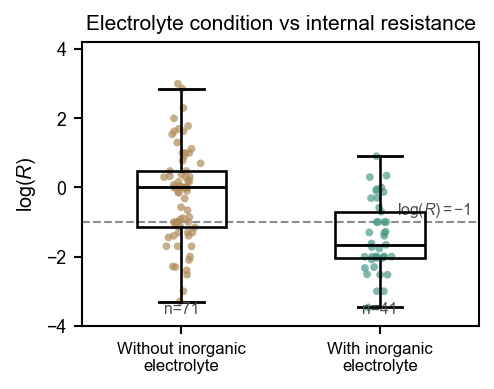

In [3]:
# =========================
# Final Fig. 5A
# Electrolyte condition vs internal resistance
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(3.35, 2.65))

inorg_order = [
    "without_inorganic_electrolyte",
    "with_inorganic_electrolyte",
]

inorg_labels = {
    "without_inorganic_electrolyte": "Without inorganic\nelectrolyte",
    "with_inorganic_electrolyte": "With inorganic\nelectrolyte",
}

plot_hollow_box_colored_scatter_R(
    ax=ax,
    df=fig5_raw,
    group_col="inorganic_electrolyte_group",
    value_col="log_R",
    order=inorg_order,
    label_map=inorg_labels,
    color_map=ELECTROLYTE_COLORS,
    title="Electrolyte condition vs internal resistance",
    ylabel=r"$\log(R)$",
    ylim=(-4.0, 4.2),
    rotate=0,
    show_n=True,
    seed=42,
)

plt.tight_layout()

save_final_panel(fig, "fig5A_final_electrolyte_condition_vs_R")

plt.show()

Saved:
 - fig5B_final_ion_type_vs_R.pdf
 - fig5B_final_ion_type_vs_R.svg
 - fig5B_final_ion_type_vs_R.png


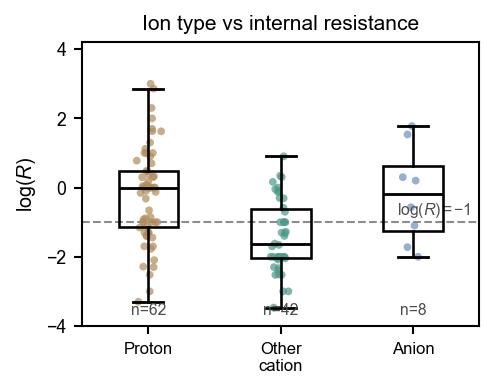

In [4]:
# =========================
# Final Fig. 5B
# Ion type vs internal resistance
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(3.35, 2.65))

ion_order = [
    "proton",
    "other_cation",
    "anion",
]

ion_labels = {
    "proton": "Proton",
    "other_cation": "Other\ncation",
    "anion": "Anion",
}

plot_hollow_box_colored_scatter_R(
    ax=ax,
    df=fig5_raw,
    group_col="ion_type_clean",
    value_col="log_R",
    order=ion_order,
    label_map=ion_labels,
    color_map=ION_COLORS,
    title="Ion type vs internal resistance",
    ylabel=r"$\log(R)$",
    ylim=(-4.0, 4.2),
    rotate=0,
    show_n=True,
    seed=42,
)

plt.tight_layout()

save_final_panel(fig, "fig5B_final_ion_type_vs_R")

plt.show()

Saved:
 - fig5C_final_structure_class_vs_R.pdf
 - fig5C_final_structure_class_vs_R.svg
 - fig5C_final_structure_class_vs_R.png


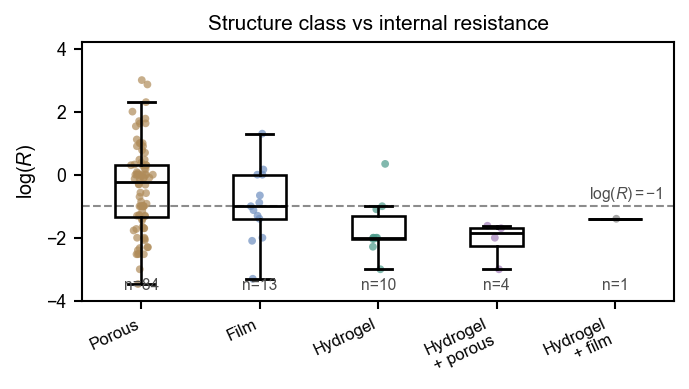

In [5]:
# =========================
# Final Fig. 5C
# Structure class vs internal resistance
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(3.35, 2.65))

# R1C6 direct structure-level inference: adequately represented groups only.
structure_order = ["porous", "film", "hydrogel"]

structure_labels = {
    "porous": "Porous",
    "film": "Film",
    "hydrogel": "Hydrogel",
}

plot_hollow_box_colored_scatter_R(
    ax=ax,
    df=fig5_raw.loc[fig5_raw["structure_class_clean"].isin(structure_order)].copy(),
    group_col="structure_class_clean",
    value_col="log_R",
    order=structure_order,
    label_map=structure_labels,
    color_map=STRUCTURE_COLORS,
    title="Structure class vs internal resistance",
    ylabel=r"$\log(R)$",
    ylim=(-4.0, 4.2),
    rotate=25,
    show_n=True,
    seed=42,
)

plt.tight_layout()

save_final_panel(fig, "fig5C_final_structure_class_vs_R")

plt.show()

In [6]:
print("Final Figure 5 panel files:")

for p in sorted(final_dir.glob("fig5*_final*")):
    print(" -", p.name)

Final Figure 5 panel files:
 - fig5A_final_electrolyte_condition_vs_R.pdf
 - fig5A_final_electrolyte_condition_vs_R.png
 - fig5A_final_electrolyte_condition_vs_R.svg
 - fig5B_final_ion_type_vs_R.pdf
 - fig5B_final_ion_type_vs_R.png
 - fig5B_final_ion_type_vs_R.svg
 - fig5C_final_structure_class_vs_R.pdf
 - fig5C_final_structure_class_vs_R.png
 - fig5C_final_structure_class_vs_R.svg
